59 classes.

In [1]:
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
image_path = glob("D:\python-venv\\U_NET\\people_clothing_seg\data\png_images\IMAGES\*.png")
mask_path = glob("D:\python-venv\\U_NET\\people_clothing_seg\data\png_masks\MASKS\*.png")

Solving the sort issue of glob

In [3]:
image_path.sort()
mask_path.sort()

In [4]:
w = []
h = []
for path in image_path:
    img = cv2.imread(path)
    w.append(img.shape[0])
    h.append(img.shape[1]) 

In [5]:
min(w)

825

In [6]:
min(h)

550

In [7]:
w = []
h = []
for path in mask_path:
    mask = cv2.imread(path)
    w.append(mask.shape[0])
    h.append(mask.shape[1]) 

In [8]:
min(w)

825

In [9]:
min(h)

550

In [10]:
input_w , input_h , output_w , output_h= 256 , 256 , 256 , 256
input_ch = 3
output_ch=1

In [11]:
images = np.zeros((len(image_path) , input_h , input_w , input_ch) , dtype=np.uint8)

In [12]:
for id_ , path in enumerate(image_path):
    img = cv2.resize(cv2.imread(path),(input_w,input_h))
    images[id_] = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

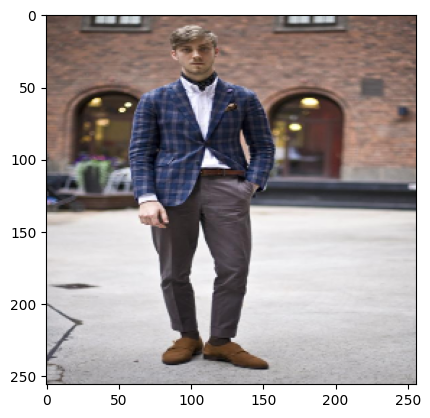

In [13]:
plt.imshow(images[7])
plt.show()

In [14]:
masks = np.zeros((len(image_path) , input_h , input_w) , dtype=np.uint8)

In [15]:
for id_,path in enumerate(mask_path):
    masks[id_] = cv2.resize(cv2.imread(path,cv2.IMREAD_GRAYSCALE) , (256,256) , interpolation=cv2.INTER_NEAREST)

In [16]:
images.shape

(1000, 256, 256, 3)

In [17]:
masks.shape

(1000, 256, 256)

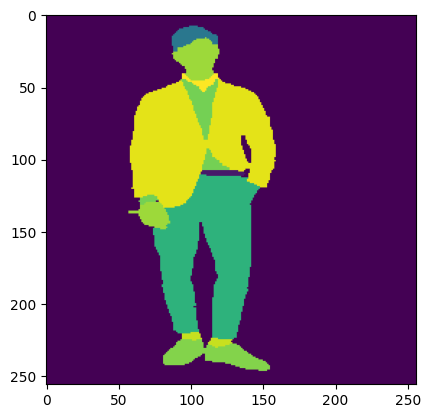

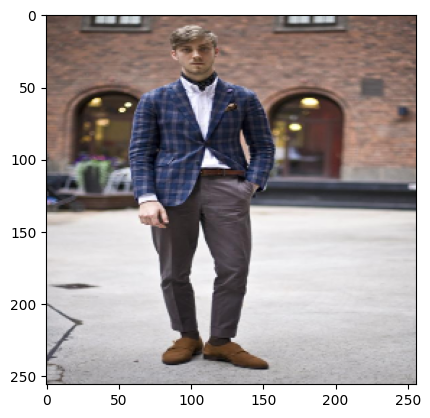

In [18]:
plt.imshow(masks[7])
plt.show()
plt.imshow(images[7])
plt.show()

In [19]:
np.unique(masks , return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 36,
        37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 51, 52, 53, 54,
        55, 56, 57, 58], dtype=uint8),
 array([50325424,    57838,   589558,    47481,   407463,   573204,
           65377,    76825,      208,     6298,   180151,    53815,
         1646555,  1794863,       90,     3935,     2448,     7348,
          826064,    65060,     6321,    11315,   295607,   699465,
           64941,   100538,    13833,     4919,  1584541,     9793,
          276081,      271,   160551,    42687,   154378,   427534,
          547293,   145094,  1918738,   561651,    11048,    15538,
          163187,   479702,    40491,   386044,    81468,   292381,
            6821,    12344,   116765,   163642,     7983,     1601,
            1429], dtype=int64))

In [20]:
images = images/255

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPool2D,Conv2DTranspose ,Input, concatenate
import pandas as pd

In [22]:
input = Input(shape=(input_w,input_h,input_ch))

conv1_encoder = Conv2D(32,(3,3),activation='relu',padding='same',name='input_gray')(input)
conv1_encoder = Conv2D(32,(3,3),activation='relu',padding='same')(conv1_encoder)
pool1_encoder = MaxPool2D((2,2))(conv1_encoder)

conv2_encoder = Conv2D(64,(3,3),activation='relu',padding='same')(pool1_encoder)
conv2_encoder = Conv2D(64,(3,3),activation='relu',padding='same')(conv2_encoder)
pool2_encoder = MaxPool2D((2,2))(conv2_encoder)

conv3_encoder = Conv2D(128,(3,3),activation='relu',padding='same')(pool2_encoder)
conv3_encoder = Conv2D(128,(3,3),activation='relu',padding='same')(conv3_encoder)
pool3_encoder = MaxPool2D((2,2))(conv3_encoder)

conv4_encoder = Conv2D(256,(3,3),activation='relu',padding='same')(pool3_encoder)
conv4_encoder = Conv2D(256,(3,3),activation='relu',padding='same')(conv4_encoder)
pool4_encoder = MaxPool2D((2,2))(conv4_encoder)

conv5_encoder = Conv2D(512,(3,3),activation='relu',padding='same')(pool4_encoder)
conv5_encoder = Conv2D(512,(3,3),activation='relu',padding='same')(conv5_encoder)

up1_decoder = Conv2DTranspose(128,(2,2),strides=(2,2),padding='same')(conv4_encoder)
concat1 = concatenate([conv3_encoder,up1_decoder])
conv1_decoder = Conv2D(256,(3,3),activation='relu',padding='same')(concat1)
conv1_decoder = Conv2D(256,(3,3),activation='relu',padding='same')(conv1_decoder)

up2_decoder = Conv2DTranspose(128,(2,2),strides=(2,2),padding='same')(conv4_encoder)
concat2 = concatenate([conv3_encoder,up2_decoder])
conv2_decoder = Conv2D(128,(3,3),activation='relu',padding='same')(concat2)
conv2_decoder = Conv2D(128,(3,3),activation='relu',padding='same')(conv2_decoder)

up3_decoder = Conv2DTranspose(64,(2,2),strides=(2,2),padding='same')(conv2_decoder)
concat3 = concatenate([conv2_encoder,up3_decoder])
conv3_decoder = Conv2D(64,(3,3),activation='relu',padding='same')(concat3)
conv3_decoder = Conv2D(64,(3,3),activation='relu',padding='same')(conv3_decoder)

up4_decoder = Conv2DTranspose(32,(2,2),strides=(2,2),padding='same')(conv3_decoder)
concat4 = concatenate([conv1_encoder,up4_decoder])
conv4_decoder = Conv2D(32,(3,3),activation='relu',padding='same')(concat4)
conv4_decoder = Conv2D(32,(3,3),activation='relu',padding='same')(conv4_decoder)

output = Conv2D(59,(1,1),activation='softmax',name='output_color')(conv4_decoder)

model = Model(inputs=[input],outputs=[output])

In [23]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_gray (Conv2D) │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      9,248 │ input_gray[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_1[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_3[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_5[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 64, 64,    │    131,200 │ conv2d_6[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64,    │          0 │ conv2d_4[0][0],   │
│ (Concatenate)       │ 256)              │            │ conv2d_transpose… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 64, 64,    │    295,040 │ concatenate_1[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_11[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 128, 128,  │     32,832 │ conv2d_12[0][0] 

 Total params: 1,927,515 (7.35 MB)

 Trainable params: 1,927,515 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
opt = tf.keras.optimizers.Adam(0.001)
loss = tf.keras.losses.SparseCategoricalCrossentropy()
model.compile(optimizer=opt,loss=loss)

: 

In [ ]:
model.fit(images,masks,validation_split=0.1,batch_size=50,epochs=25,verbose=2)

Epoch 1/25
18/18 - 262s - 15s/step - loss: 2.3071 - val_loss: 1.5483
Epoch 2/25
18/18 - 255s - 14s/step - loss: 1.3875 - val_loss: 1.3163
Epoch 3/25
18/18 - 258s - 14s/step - loss: 1.1650 - val_loss: 1.1201
Epoch 4/25
18/18 - 257s - 14s/step - loss: 1.0532 - val_loss: 1.0486
Epoch 5/25
18/18 - 258s - 14s/step - loss: 1.0052 - val_loss: 1.0213
Epoch 6/25
18/18 - 258s - 14s/step - loss: 0.9937 - val_loss: 1.0469
Epoch 7/25
18/18 - 258s - 14s/step - loss: 0.9882 - val_loss: 0.9969
Epoch 8/25


In [ ]:
pred = model.predict(images[:5])

In [ ]:
pred.shape

In [ ]:
pred_masks = np.argmax(pred,axis=-1)

In [ ]:
plt.figure(figsize=(8, 4))
index = 5
plt.subplot(1, 3, 1)
plt.imshow(images[index])
plt.title('Image')

plt.subplot(1, 3, 2)
plt.imshow(masks[index], cmap='gray')
plt.title('Masks')

plt.subplot(1, 3, 3)
plt.imshow(pred_masks[index] , cmap='gray')
plt.title('Predicted Mask')

plt.show()

In [ ]:
labels = pd.read_csv("D:\python-venv\\U_NET\\people_clothing_seg\data\labels.csv")

In [ ]:
labels

,Unnamed: 0,label_list
0,0,NaN
1,1,accessories
2,2,bag
3,3,belt
4,4,blazer
5,5,blouse
6,6,bodysuit
7,7,boots
8,8,bra
9,9,bracelet
